In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [5]:
df = pd.read_csv(r'E:\Rnw\algorithms\Predictive Insight Engine\scaleddata.csv')

In [6]:
df.head()

,Unnamed: 0,house_id,area_scaled,bedrooms_scaled,bathrooms_scaled,location_score_scaled,age_years_scaled,distance_city_km_scaled,lot_size_sqft_scaled,has_garage_scaled,has_pool_scaled,renovation_years_ago_scaled,house_price_scaled
0,1,100002,0.425857,0.333333,0.5,0.575622,0.180542,0.423942,0.591241,1.0,0.0,0.778239,0.583820
1,2,100003,0.597446,0.333333,0.5,0.518943,0.041060,0.547232,0.667836,0.0,0.0,0.666667,0.616055
2,3,100004,0.778626,0.666667,0.5,0.735254,0.148655,0.221874,0.555152,1.0,1.0,0.420620,0.819712
3,4,100005,0.404316,0.333333,0.5,0.294410,0.239792,0.611922,0.412729,0.0,0.0,0.821658,0.451822
4,5,100006,0.404316,0.333333,0.0,0.700940,0.041060,0.362911,0.304427,0.0,0.0,0.666667,0.579014


In [7]:
df.columns

Index(['Unnamed: 0', 'house_id', 'area_scaled', 'bedrooms_scaled',
       'bathrooms_scaled', 'location_score_scaled', 'age_years_scaled',
       'distance_city_km_scaled', 'lot_size_sqft_scaled', 'has_garage_scaled',
       'has_pool_scaled', 'renovation_years_ago_scaled', 'house_price_scaled'],
      dtype='object')

In [8]:
df = df.drop("Unnamed: 0", axis=1)
df = df.drop("house_id", axis=1)


In [9]:
df.columns

Index(['area_scaled', 'bedrooms_scaled', 'bathrooms_scaled',
       'location_score_scaled', 'age_years_scaled', 'distance_city_km_scaled',
       'lot_size_sqft_scaled', 'has_garage_scaled', 'has_pool_scaled',
       'renovation_years_ago_scaled', 'house_price_scaled'],
      dtype='object')

In [10]:
X = df.drop("house_price_scaled", axis=1)   # independent variable(s)
y = df["house_price_scaled"]                # dependent variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

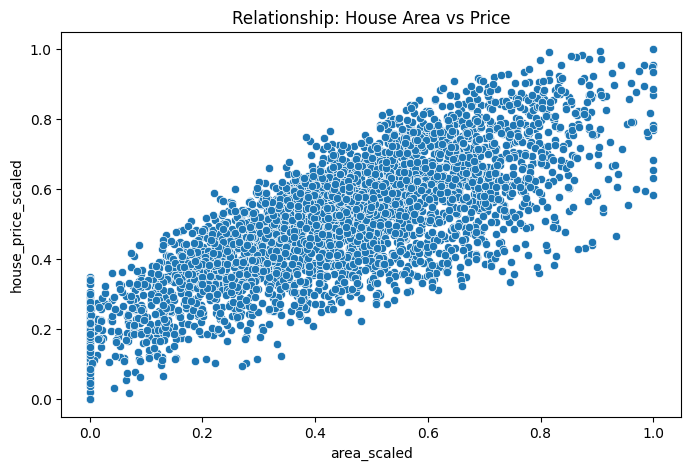

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='area_scaled', y='house_price_scaled', data=df)
plt.title('Relationship: House Area vs Price')
plt.show()

In [12]:
df.shape

(3725, 11)

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
y_pred = model.predict(X_test)

In [15]:
mse = mean_squared_error(y_test, y_pred)

In [16]:
mae = mean_absolute_error(y_test, y_pred)

In [17]:
rmse = np.sqrt(mse)

In [18]:
r2 = r2_score(y_test, y_pred)

In [19]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

In [20]:
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("Adjusted R2:", adjusted_r2)

MSE: 0.0014201783735936229
MAE: 0.028855112114268475
RMSE: 0.03768525406035659
R2 Score: 0.9560449618230087
Adjusted R2: 0.9554461193410333


In [21]:
df.columns

Index(['area_scaled', 'bedrooms_scaled', 'bathrooms_scaled',
       'location_score_scaled', 'age_years_scaled', 'distance_city_km_scaled',
       'lot_size_sqft_scaled', 'has_garage_scaled', 'has_pool_scaled',
       'renovation_years_ago_scaled', 'house_price_scaled'],
      dtype='object')

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Simple regression feature
X_simple = df[['area_scaled']]
y = df['house_price_scaled']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.25, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

y_pred_simple = model_simple.predict(X_test_s)

mse_simple = mean_squared_error(y_test_s, y_pred_simple)
r2_simple = r2_score(y_test_s, y_pred_simple)

print("Simple Regression MSE:", mse_simple)
print("Simple Regression R2:", r2_simple)

Simple Regression MSE: 0.012972320361629696
Simple Regression R2: 0.5955774747558096


In [24]:
# Multiple regression features
X_multi = df.drop("house_price_scaled", axis=1)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.25, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

y_pred_multi = model_multi.predict(X_test_m)

mse_multi = mean_squared_error(y_test_m, y_pred_multi)
r2_multi = r2_score(y_test_m, y_pred_multi)

print("Multiple Regression MSE:", mse_multi)
print("Multiple Regression R2:", r2_multi)

Multiple Regression MSE: 0.001426767069998256
Multiple Regression R2: 0.9555193885674699


In [32]:
linear_model = LinearRegression()
linear_model.fit(X_train_s, y_train_s)

y_pred_linear = linear_model.predict(X_test_s)

In [33]:
poly = PolynomialFeatures(degree=2)  

X_train_poly = poly.fit_transform(X_train_s)
X_test_poly = poly.transform(X_test_s)

In [34]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_s)

y_pred_poly = poly_model.predict(X_test_poly)

In [35]:
mse_linear = mean_squared_error(y_test_s, y_pred_linear)
r2_linear = r2_score(y_test_s, y_pred_linear)

mse_poly = mean_squared_error(y_test_s, y_pred_poly)
r2_poly = r2_score(y_test_s, y_pred_poly)

print("Linear Regression MSE:", mse_linear)
print("Linear Regression R2:", r2_linear)

print("Polynomial Regression MSE:", mse_poly)
print("Polynomial Regression R2:", r2_poly)

Linear Regression MSE: 0.012972320361629696
Linear Regression R2: 0.5955774747558096
Polynomial Regression MSE: 0.01265895113775684
Polynomial Regression R2: 0.6053470124575868


e:\Rnw\dataprofiler\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
e:\Rnw\dataprofiler\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


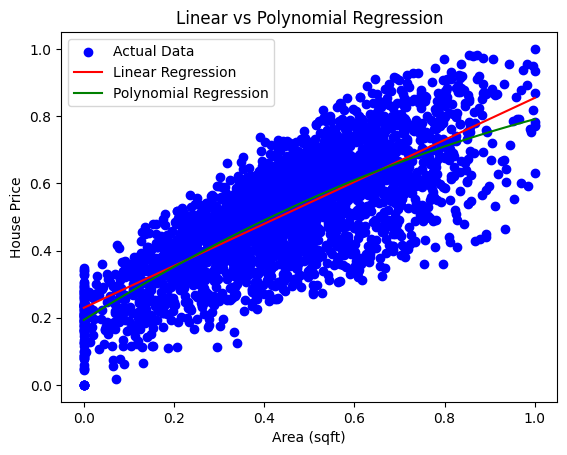

In [37]:
import numpy as np
import matplotlib.pyplot as plt

X_grid = np.linspace(X_train_s.min(), X_train_s.max(), 100).reshape(-1,1)

plt.scatter(X_train_s, y_train_s, color="blue", label="Actual Data")

# Linear regression line
plt.plot(X_grid, linear_model.predict(X_grid), color="red", label="Linear Regression")

# Polynomial regression curve
plt.plot(
    X_grid,
    poly_model.predict(poly.transform(X_grid)),
    color="green",
    label="Polynomial Regression"
)

plt.xlabel("Area (sqft)")
plt.ylabel("House Price")
plt.title("Linear vs Polynomial Regression")

plt.legend()
plt.show()

In [38]:
df.columns

Index(['area_scaled', 'bedrooms_scaled', 'bathrooms_scaled',
       'location_score_scaled', 'age_years_scaled', 'distance_city_km_scaled',
       'lot_size_sqft_scaled', 'has_garage_scaled', 'has_pool_scaled',
       'renovation_years_ago_scaled', 'house_price_scaled'],
      dtype='object')

In [39]:
import numpy as np

# Example data
X = df[['area_scaled']].values
y = df['house_price_scaled'].values.reshape(-1,1)

# Add bias column
X = np.c_[np.ones((X.shape[0],1)), X]

# Initialize parameters
theta = np.zeros((X.shape[1],1))

learning_rate = 0.0000001
epochs = 1000
m = len(y)

for i in range(epochs):
    
    predictions = X.dot(theta)
    
    error = predictions - y
    
    gradient = (1/m) * X.T.dot(error)
    
    theta = theta - learning_rate * gradient

print("Batch GD Parameters:", theta)

Batch GD Parameters: [[5.11602590e-05]
 [2.59680216e-05]]


In [40]:


# Example data
X = df[['area_scaled']].values
y = df['house_price_scaled'].values.reshape(-1,1)

# Add bias column
X = np.c_[np.ones((X.shape[0],1)), X]

# Initialize parameters
theta = np.zeros((X.shape[1],1))

learning_rate = 0.0000001
epochs = 1000
m = len(y)

for i in range(epochs):
    
    predictions = X.dot(theta)
    
    error = predictions - y
    
    gradient = (1/m) * X.T.dot(error)
    
    theta = theta - learning_rate * gradient

print("Batch GD Parameters:", theta)

Batch GD Parameters: [[5.11602590e-05]
 [2.59680216e-05]]


In [41]:
theta = np.zeros((X.shape[1],1))

learning_rate = 0.0000001
epochs = 50
m = len(y)

for epoch in range(epochs):
    
    for i in range(m):
        
        xi = X[i:i+1]
        yi = y[i:i+1]
        
        prediction = xi.dot(theta)
        
        error = prediction - yi
        
        gradient = xi.T.dot(error)
        
        theta = theta - learning_rate * gradient

print("SGD Parameters:", theta)

SGD Parameters: [[0.00942095]
 [0.00478598]]


In [42]:
theta = np.zeros((X.shape[1],1))

learning_rate = 0.0000001
epochs = 100
batch_size = 32
m = len(y)

for epoch in range(epochs):
    
    for i in range(0, m, batch_size):
        
        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]
        
        prediction = X_batch.dot(theta)
        
        error = prediction - y_batch
        
        gradient = (1/len(X_batch)) * X_batch.T.dot(error)
        
        theta = theta - learning_rate * gradient

print("Mini-batch GD Parameters:", theta)

Mini-batch GD Parameters: [[0.0005978 ]
 [0.00030332]]


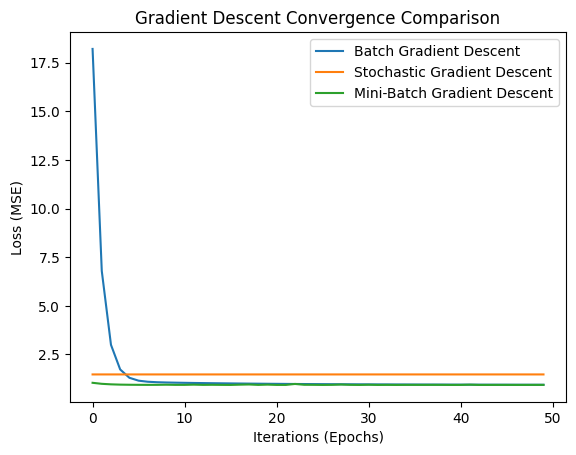

In [43]:
# Visualization of Gradient Descent convergence (Batch vs SGD vs Mini-Batch)
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic linear data
np.random.seed(42)
m = 200
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

# Add bias term
X_b = np.c_[np.ones((m, 1)), X]

def mse(X, y, theta):
    preds = X.dot(theta)
    return np.mean((preds - y) ** 2)

# -------- Batch Gradient Descent --------
theta_batch = np.zeros((2,1))
lr = 0.1
epochs = 50
loss_batch = []

for _ in range(epochs):
    gradients = (2/m) * X_b.T.dot(X_b.dot(theta_batch) - y)
    theta_batch -= lr * gradients
    loss_batch.append(mse(X_b, y, theta_batch))

# -------- Stochastic Gradient Descent --------
theta_sgd = np.zeros((2,1))
loss_sgd = []

for _ in range(epochs):
    for i in range(m):
        xi = X_b[i:i+1]
        yi = y[i:i+1]
        gradients = 2 * xi.T.dot(xi.dot(theta_sgd) - yi)
        theta_sgd -= lr * gradients
    loss_sgd.append(mse(X_b, y, theta_sgd))

# -------- Mini-Batch Gradient Descent --------
theta_mb = np.zeros((2,1))
batch_size = 20
loss_mb = []

for _ in range(epochs):
    indices = np.random.permutation(m)
    X_shuffled = X_b[indices]
    y_shuffled = y[indices]
    
    for i in range(0, m, batch_size):
        xi = X_shuffled[i:i+batch_size]
        yi = y_shuffled[i:i+batch_size]
        gradients = (2/len(xi)) * xi.T.dot(xi.dot(theta_mb) - yi)
        theta_mb -= lr * gradients
        
    loss_mb.append(mse(X_b, y, theta_mb))

# Plot convergence
plt.figure()
plt.plot(loss_batch, label="Batch Gradient Descent")
plt.plot(loss_sgd, label="Stochastic Gradient Descent")
plt.plot(loss_mb, label="Mini-Batch Gradient Descent")
plt.xlabel("Iterations (Epochs)")
plt.ylabel("Loss (MSE)")
plt.title("Gradient Descent Convergence Comparison")
plt.legend()
plt.show()